# ORAS5 + ERA5 ConvLSTM: one-step-ahead evaluation

This notebook loads the previously saved monthly tensor directly from:

`C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc`

It evaluates the model using **one-step-ahead prediction**, following the same general evaluation principle as Shreya's work:

- every target month is predicted from the preceding 12 **observed** months;
- predictions are **not** fed back into the model;
- January 1982–December 1986 therefore consists of 60 separate one-month forecasts

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.21.0
Visible GPUs: []


In [2]:
# Config
CACHE_PATH = Path(
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed"
    r"\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc"
)

OUTPUT_DIR = CACHE_PATH.parent / "ConvLSTM_one_step_1982_1986_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "best_one_step_convlstm.keras"
SCALER_PATH = OUTPUT_DIR / "one_step_scaler.pkl"
HISTORY_PATH = OUTPUT_DIR / "one_step_training_history.json"

LOOKBACK = 12

VALIDATION_START = pd.Timestamp("1977-01-01")
TEST_START = pd.Timestamp("1982-01-01")
TEST_END = pd.Timestamp("1986-12-01")

EPOCHS = 50
BATCH_SIZE = 4
LEARNING_RATE = 1e-3

PRIMARY_FEATURE = "sst"

TRAIN_MODEL = True

print("Tensor:", CACHE_PATH)
print("Output directory:", OUTPUT_DIR)


Tensor: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc
Output directory: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_one_step_1982_1986_results


## 1. Load and inspect the cached tensor

In [3]:
# Load tensor

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cached tensor not found:\n{CACHE_PATH}\n"
        "Check that the path is correct and that the drive is available."
    )

with xr.open_dataset(CACHE_PATH, engine="h5netcdf") as ds:
    if "climate" in ds.data_vars:
        combined_monthly = ds["climate"].load()
    elif len(ds.data_vars) == 1:
        combined_monthly = ds[list(ds.data_vars)[0]].load()
    else:
        raise ValueError(
            "Could not identify the tensor variable. "
            f"Available data variables: {list(ds.data_vars)}"
        )

combined_monthly = (
    combined_monthly
    .sortby("time")
    .transpose("time", "feature", "lat", "lon")
    .where(np.abs(combined_monthly) < 1e10)
    .astype(np.float32)
)

# Drop features with no finite values
finite_fraction = {}
for feature_name in combined_monthly.feature.values.astype(str):
    values = combined_monthly.sel(feature=feature_name).values
    finite_fraction[feature_name] = float(np.isfinite(values).mean())

empty_features = [
    name for name, fraction in finite_fraction.items()
    if fraction == 0
]

if empty_features:
    print("Dropping completely empty features:", empty_features)
    combined_monthly = combined_monthly.drop_sel(feature=empty_features)

# Drop features with effectively zero variance over the full available tensor.
# In the current box this is expected to remove ERA5 runoff if it is all zero.
near_constant_features = []
for feature_name in combined_monthly.feature.values.astype(str):
    values = combined_monthly.sel(feature=feature_name).values
    variance = float(np.nanvar(values))
    if not np.isfinite(variance) or variance < 1e-12:
        near_constant_features.append(feature_name)

if near_constant_features:
    print("Dropping zero-variance features:", near_constant_features)
    combined_monthly = combined_monthly.drop_sel(
        feature=near_constant_features
    )

times = pd.DatetimeIndex(combined_monthly.time.values)
features = combined_monthly.feature.values.astype(str).tolist()
lats = combined_monthly.lat.values
lons = combined_monthly.lon.values

print(combined_monthly)
print("Shape:", combined_monthly.shape)
print("Features:", features)
print("Time range:", times.min(), "to", times.max())


Dropping completely empty features: ['era5_u10', 'era5_v10', 'era5_d2m', 'era5_skt', 'era5_stl2', 'era5_swvl1']
Dropping zero-variance features: ['era5_runoff']
<xarray.DataArray 'climate' (time: 731, feature: 7, lat: 41, lon: 41)> Size: 34MB
array([[[[ 2.35199757e+01,  2.34769897e+01,  2.33609905e+01, ...,
           2.20119190e+01,  2.19966621e+01,  2.19995861e+01],
         [ 2.32970276e+01,  2.32798328e+01,  2.31490097e+01, ...,
           2.18421974e+01,  2.18343105e+01,  2.18372135e+01],
         [ 2.30233097e+01,  2.30007381e+01,  2.28932953e+01, ...,
           2.16560059e+01,  2.16852074e+01,  2.17373257e+01],
         ...,
         [ 4.22588348e+00,  3.54310250e+00,  3.41622806e+00, ...,
           1.45103941e+01,  1.44450855e+01,  1.41717777e+01],
         [ 3.99747515e+00,  3.35775614e+00,  2.87952423e+00, ...,
           1.43481550e+01,  1.42319508e+01,  1.40277977e+01],
         [ 3.40464163e+00,  2.70291519e+00,  2.36959958e+00, ...,
           1.39985895e+01,  1.4089990

In [4]:
# Data quality

quality_rows = []

for feature_name in features:
    values = combined_monthly.sel(feature=feature_name).values
    finite = np.isfinite(values)

    quality_rows.append({
        "feature": feature_name,
        "finite_fraction": finite.mean(),
        "n_finite": int(finite.sum()),
        "n_nan": int(np.isnan(values).sum()),
        "minimum": np.nanmin(values) if finite.any() else np.nan,
        "maximum": np.nanmax(values) if finite.any() else np.nan,
        "mean": np.nanmean(values) if finite.any() else np.nan,
        "std": np.nanstd(values) if finite.any() else np.nan,
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

expected_months = pd.date_range(times.min(), times.max(), freq="MS")
missing_months = expected_months.difference(times)

print("\nMissing complete months:", len(missing_months))
print([timestamp.strftime("%Y-%m") for timestamp in missing_months])

if TEST_START < times.min() or TEST_END > times.max():
    raise ValueError(
        "The requested test period is not fully present in the cached tensor."
    )


,feature,finite_fraction,n_finite,n_nan,minimum,maximum,mean,std
0,sst,1.0,1228811,0,-1.086443,29.103378,20.816198,4.073370
1,salinity,1.0,1228811,0,31.974577,37.904125,36.487564,0.693835
2,thetao,1.0,1228811,0,-0.754221,27.566723,19.974968,3.662420
3,qnet,1.0,1228811,0,-2465.611328,795.877258,-27.410643,173.339310
4,u_current,1.0,1228811,0,-0.737780,1.262271,0.022641,0.083298
5,v_current,1.0,1228811,0,-0.940679,1.078423,-0.006560,0.080921
6,era5_sst,1.0,1228811,0,-1.291351,29.069733,20.814356,4.127034



Missing complete months: 1
['1979-02']


## 2. Training-only imputation and normalisation

In [5]:
raw_data = (
    combined_monthly
    .transpose("time", "lat", "lon", "feature")
    .values
    .astype(np.float32)
)

train_fit_mask = times < VALIDATION_START

if train_fit_mask.sum() == 0:
    raise ValueError("No data exist before VALIDATION_START.")

training_reference = raw_data[train_fit_mask]

month_climatology = np.full(
    (12, raw_data.shape[1], raw_data.shape[2], raw_data.shape[3]),
    np.nan,
    dtype=np.float32,
)

for month in range(1, 13):
    month_mask = train_fit_mask & (times.month == month)
    month_climatology[month - 1] = np.nanmean(
        raw_data[month_mask],
        axis=0,
    )

cell_mean = np.nanmean(training_reference, axis=0)

feature_median = np.nanmedian(
    training_reference.reshape(-1, training_reference.shape[-1]),
    axis=0,
).astype(np.float32)


def impute_array(values, value_times):
    values = np.array(values, dtype=np.float32, copy=True)
    value_times = pd.DatetimeIndex(value_times)

    for index, timestamp in enumerate(value_times):
        missing = ~np.isfinite(values[index])

        if missing.any():
            monthly_fill = month_climatology[timestamp.month - 1]
            values[index][missing] = monthly_fill[missing]

        missing = ~np.isfinite(values[index])

        if missing.any():
            values[index][missing] = cell_mean[missing]

        missing = ~np.isfinite(values[index])

        if missing.any():
            fallback = np.broadcast_to(
                feature_median,
                values[index].shape,
            )
            values[index][missing] = fallback[missing]

    if not np.isfinite(values).all():
        raise ValueError("Imputation left non-finite values.")

    return values


data_filled = impute_array(raw_data, times)

fit_values = data_filled[train_fit_mask]

feature_mean = fit_values.mean(axis=(0, 1, 2)).astype(np.float32)
feature_std = fit_values.std(axis=(0, 1, 2)).astype(np.float32)

feature_std = np.where(
    feature_std < 1e-8,
    1.0,
    feature_std,
).astype(np.float32)

data_scaled = (
    data_filled - feature_mean
) / feature_std

scaler = {
    "features": features,
    "mean": feature_mean,
    "std": feature_std,
    "month_climatology": month_climatology,
    "cell_mean": cell_mean,
    "feature_median": feature_median,
    "fit_end": str(times[train_fit_mask][-1]),
}

with open(SCALER_PATH, "wb") as file:
    pickle.dump(scaler, file)

print("All scaled values finite:", np.isfinite(data_scaled).all())
print("Saved scaler:", SCALER_PATH)


All scaled values finite: True
Saved scaler: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_one_step_1982_1986_results\one_step_scaler.pkl


## 3. Create one-step-ahead samples

In [6]:
# Create sequences

def months_are_consecutive(months):
    months = pd.DatetimeIndex(months)
    expected = pd.date_range(
        months[0],
        periods=len(months),
        freq="MS",
    )
    return months.equals(expected)


def create_sequences(values, value_times, lookback=12):
    X = []
    y = []
    target_times = []

    value_times = pd.DatetimeIndex(value_times)

    for target_index in range(lookback, len(value_times)):
        sequence_times = value_times[
            target_index - lookback:target_index + 1
        ]

        if not months_are_consecutive(sequence_times):
            continue

        X.append(values[target_index - lookback:target_index])
        y.append(values[target_index])
        target_times.append(value_times[target_index])

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DatetimeIndex(target_times),
    )


X_all, y_all, target_times = create_sequences(
    data_scaled,
    times,
    lookback=LOOKBACK,
)

train_mask = target_times < VALIDATION_START

validation_mask = (
    (target_times >= VALIDATION_START)
    & (target_times < TEST_START)
)

test_mask = (
    (target_times >= TEST_START)
    & (target_times <= TEST_END)
)

X_train = X_all[train_mask]
y_train = y_all[train_mask]
train_times = target_times[train_mask]

X_val = X_all[validation_mask]
y_val = y_all[validation_mask]
val_times = target_times[validation_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]
test_times = target_times[test_mask]

print("X_train:", X_train.shape, "|", train_times[0], "to", train_times[-1])
print("X_val:  ", X_val.shape, "|", val_times[0], "to", val_times[-1])
print("X_test: ", X_test.shape, "|", test_times[0], "to", test_times[-1])

if min(len(X_train), len(X_val), len(X_test)) == 0:
    raise ValueError("At least one chronological split is empty.")


X_train: (216, 12, 41, 41, 7) | 1959-01-01 00:00:00 to 1976-12-01 00:00:00
X_val:   (47, 12, 41, 41, 7) | 1977-01-01 00:00:00 to 1981-12-01 00:00:00
X_test:  (60, 12, 41, 41, 7) | 1982-01-01 00:00:00 to 1986-12-01 00:00:00


## 4. ConvLSTM model

In [7]:
# Model

_, n_steps, n_lat, n_lon, n_features = X_train.shape

model = Sequential([
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(
            n_steps,
            n_lat,
            n_lon,
            n_features,
        ),
    ),
    BatchNormalization(),

    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
    ),
    BatchNormalization(),

    ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False,
    ),
    BatchNormalization(),

    Conv2D(
        filters=n_features,
        kernel_size=(3, 3),
        padding="same",
        activation="linear",
    ),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="mse",
    metrics=["mae"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 12, 41, 41, 32)      │          45,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 41, 41, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 12, 41, 41, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 41, 41, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)           │ (None, 41, 41, 16)          │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 41, 41, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 41, 41, 7)           │           1,015 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 147,959 (577.96 KB)

 Trainable params: 147,799 (577.34 KB)

 Non-trainable params: 160 (640.00 B)

In [8]:
# Train/load model

if TRAIN_MODEL:
    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
        ModelCheckpoint(
            MODEL_PATH,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        shuffle=False,
        verbose=1,
    )

    history_data = {
        key: [float(value) for value in values]
        for key, values in history.history.items()
    }

    with open(HISTORY_PATH, "w") as file:
        json.dump(history_data, file, indent=2)

else:
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"TRAIN_MODEL=False, but no model exists at {MODEL_PATH}"
        )

    model = load_model(MODEL_PATH)

    if not HISTORY_PATH.exists():
        raise FileNotFoundError(
            f"Training history not found at {HISTORY_PATH}"
        )

    with open(HISTORY_PATH) as file:
        history_data = json.load(file)

model = load_model(MODEL_PATH)

print("Best model loaded from:", MODEL_PATH)


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - loss: 1.0439 - mae: 0.7026
Epoch 1: val_loss improved from None to 0.71089, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_one_step_1982_1986_results\best_one_step_convlstm.keras

Epoch 1: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_one_step_1982_1986_results\best_one_step_convlstm.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 729ms/step - loss: 0.7020 - mae: 0.5695 - val_loss: 0.7109 - val_mae: 0.5666 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - loss: 0.4588 - mae: 0.4619
Epoch 2: val_loss improved from 0.71089 to 0.66954, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_one_step_1982_1986_results\best_one_step_convlstm.keras

Epoch 2: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_one_step_1982_1986_results\best_one_step_convlstm.keras
54/

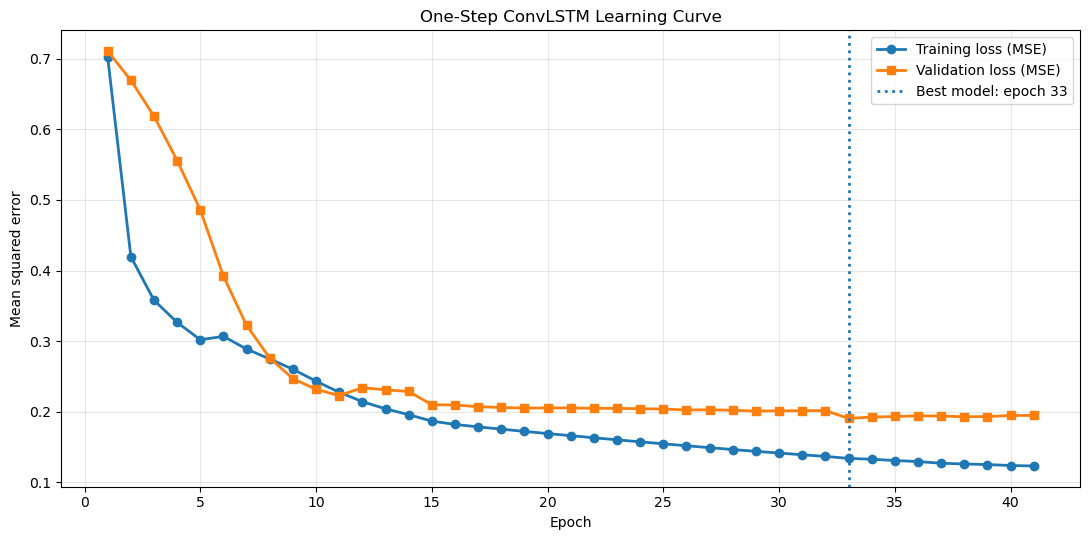

Best epoch: 33
Best validation MSE: 0.19065721333026886


In [9]:
# Learning curve

train_loss = np.asarray(history_data["loss"])
val_loss = np.asarray(history_data["val_loss"])

epochs_ran = np.arange(1, len(train_loss) + 1)
best_epoch = int(np.argmin(val_loss) + 1)

plt.figure(figsize=(11, 5.5))

plt.plot(
    epochs_ran,
    train_loss,
    marker="o",
    linewidth=2,
    label="Training loss (MSE)",
)

plt.plot(
    epochs_ran,
    val_loss,
    marker="s",
    linewidth=2,
    label="Validation loss (MSE)",
)

plt.axvline(
    best_epoch,
    linestyle=":",
    linewidth=2,
    label=f"Best model: epoch {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("One-Step ConvLSTM Learning Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Best epoch:", best_epoch)
print("Best validation MSE:", val_loss[best_epoch - 1])


## 5. Generate the 60 independent one-step forecasts

Each of the 60 test samples contains the true preceding observations (no recursive roll-forward).


In [10]:
# Test predictions

def inverse_scale(values):
    return values * feature_std + feature_mean


y_test_pred_scaled = model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1,
)

y_test_true = inverse_scale(y_test)
y_test_pred = inverse_scale(y_test_pred_scaled)

print("Test dates:", test_times[0], "to", test_times[-1])
print("Truth shape:", y_test_true.shape)
print("Prediction shape:", y_test_pred.shape)


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step
Test dates: 1982-01-01 00:00:00 to 1986-12-01 00:00:00
Truth shape: (60, 41, 41, 7)
Prediction shape: (60, 41, 41, 7)


In [11]:
# Helpers

def safe_metrics(actual, predicted):
    actual = np.asarray(actual).ravel()
    predicted = np.asarray(predicted).ravel()

    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
    )

    actual = actual[valid]
    predicted = predicted[valid]

    if len(actual) == 0:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "Bias": np.nan,
            "Pearson_r": np.nan,
            "n_valid": 0,
        }

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted) if len(actual) > 1 else np.nan
    bias = np.mean(predicted - actual)

    if (
        len(actual) > 1
        and np.std(actual) > 0
        and np.std(predicted) > 0
    ):
        correlation = pearsonr(actual, predicted).statistic
    else:
        correlation = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias,
        "Pearson_r": correlation,
        "n_valid": int(len(actual)),
    }


def feature_metrics_table(actual, predicted, feature_names):
    rows = []

    for feature_index, feature_name in enumerate(feature_names):
        row = {"feature": feature_name}
        row.update(
            safe_metrics(
                actual[..., feature_index],
                predicted[..., feature_index],
            )
        )
        rows.append(row)

    return pd.DataFrame(rows)


In [12]:
# Metrics

one_step_metrics_df = feature_metrics_table(
    y_test_true,
    y_test_pred,
    features,
)

display(one_step_metrics_df)


,feature,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,sst,0.683956,0.974851,0.941287,0.036098,0.972203,100860
1,salinity,0.113456,0.154358,0.945453,-0.026124,0.975591,100860
2,thetao,0.514191,0.762205,0.955660,0.082645,0.979171,100860
3,qnet,50.685005,84.203573,0.755732,2.375829,0.869933,100860
4,u_current,0.029076,0.055812,0.549751,-0.001067,0.746908,100860
5,v_current,0.029288,0.054287,0.525138,0.001467,0.732761,100860
6,era5_sst,0.736794,1.023042,0.938353,-0.109347,0.970200,100860


In [13]:
# Persistence Baseline

persistence_pred_scaled = X_test[:, -1]
persistence_pred = inverse_scale(persistence_pred_scaled)

baseline_rows = []

for feature_index, feature_name in enumerate(features):
    actual = y_test_true[..., feature_index]
    conv = y_test_pred[..., feature_index]
    persistence = persistence_pred[..., feature_index]

    conv_metrics = safe_metrics(actual, conv)
    persistence_metrics = safe_metrics(actual, persistence)

    if persistence_metrics["RMSE"] > 0:
        rmse_skill = (
            1
            - conv_metrics["RMSE"]
            / persistence_metrics["RMSE"]
        )
    else:
        rmse_skill = np.nan

    baseline_rows.append({
        "feature": feature_name,
        "ConvLSTM_MAE": conv_metrics["MAE"],
        "Persistence_MAE": persistence_metrics["MAE"],
        "ConvLSTM_RMSE": conv_metrics["RMSE"],
        "Persistence_RMSE": persistence_metrics["RMSE"],
        "RMSE_skill_vs_persistence": rmse_skill,
        "ConvLSTM_R2": conv_metrics["R2"],
        "Persistence_R2": persistence_metrics["R2"],
    })

baseline_comparison_df = pd.DataFrame(baseline_rows)
display(baseline_comparison_df)


,feature,ConvLSTM_MAE,Persistence_MAE,ConvLSTM_RMSE,Persistence_RMSE,RMSE_skill_vs_persistence,ConvLSTM_R2,Persistence_R2
0,sst,0.683956,1.230123,0.974851,1.496828,0.348722,0.941287,0.861579
1,salinity,0.113456,0.057997,0.154358,0.099697,-0.548261,0.945453,0.977245
2,thetao,0.514191,0.901815,0.762205,1.075063,0.291014,0.955660,0.911789
3,qnet,50.685005,71.572296,84.203573,105.049728,0.198441,0.755732,0.619815
4,u_current,0.029076,0.031438,0.055812,0.062130,0.101700,0.549751,0.442032
5,v_current,0.029288,0.033481,0.054287,0.062615,0.133001,0.525138,0.368272
6,era5_sst,0.736794,1.226716,1.023042,1.509305,0.322177,0.938353,0.865824


In [14]:


primary_index = features.index(PRIMARY_FEATURE)

period_rows = []

for n_years in range(1, 6):
    n_months = n_years * 12

    metrics = safe_metrics(
        y_test_true[:n_months, ..., primary_index],
        y_test_pred[:n_months, ..., primary_index],
    )

    period_rows.append({
        "evaluation_period": (
            f"{n_years} year"
            if n_years == 1
            else f"{n_years} years"
        ),
        "start": test_times[0].strftime("%Y-%m"),
        "end": test_times[n_months - 1].strftime("%Y-%m"),
        **metrics,
    })

forecast_period_metrics_df = pd.DataFrame(period_rows)
display(forecast_period_metrics_df)


,evaluation_period,start,end,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,1 year,1982-01,1982-12,0.730371,1.004665,0.941616,0.067173,0.973924,20172
1,2 years,1982-01,1983-12,0.662728,0.934515,0.944379,0.015959,0.973960,40344
2,3 years,1982-01,1984-12,0.649954,0.932394,0.943367,0.030524,0.973251,60516
3,4 years,1982-01,1985-12,0.676457,0.965759,0.941389,0.067496,0.972367,80688
4,5 years,1982-01,1986-12,0.683956,0.974851,0.941287,0.036098,0.972203,100860


In [15]:
# Metrics by year

year_rows = []

for year in range(TEST_START.year, TEST_END.year + 1):
    year_mask = test_times.year == year

    for feature_index, feature_name in enumerate(features):
        row = {
            "year": year,
            "feature": feature_name,
        }

        row.update(
            safe_metrics(
                y_test_true[year_mask, ..., feature_index],
                y_test_pred[year_mask, ..., feature_index],
            )
        )

        year_rows.append(row)

yearly_metrics_df = pd.DataFrame(year_rows)

display(
    yearly_metrics_df[
        yearly_metrics_df["feature"] == PRIMARY_FEATURE
    ].reset_index(drop=True)
)


,year,feature,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,1982,sst,0.730371,1.004665,0.941616,0.067173,0.973924,20172
1,1983,sst,0.595085,0.858653,0.947688,-0.035255,0.974570,20172
2,1984,sst,0.624405,0.928138,0.941196,0.059655,0.971814,20172
3,1985,sst,0.755969,1.059568,0.935933,0.178409,0.970329,20172
4,1986,sst,0.713949,1.010401,0.940798,-0.089493,0.972106,20172


## 6. SST plots

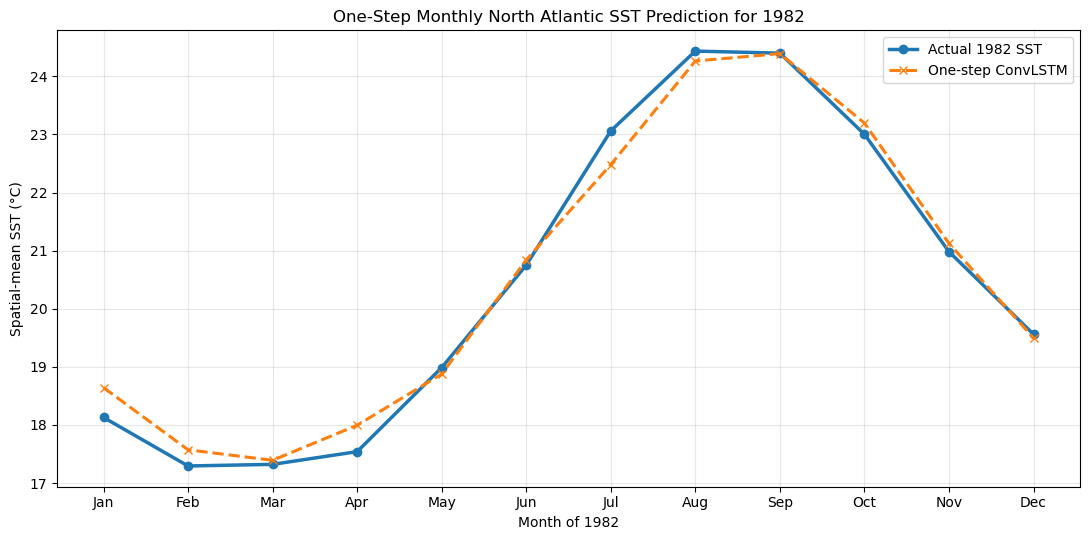

In [17]:
# Monthly box avg sst for one year

PLOT_YEAR = 1982
year_mask = test_times.year == PLOT_YEAR

actual_monthly_mean = np.nanmean(
    y_test_true[year_mask, ..., primary_index],
    axis=(1, 2),
)

predicted_monthly_mean = np.nanmean(
    y_test_pred[year_mask, ..., primary_index],
    axis=(1, 2),
)

months = test_times[year_mask].strftime("%b")

plt.figure(figsize=(11, 5.5))

plt.plot(
    months,
    actual_monthly_mean,
    marker="o",
    linewidth=2.5,
    label=f"Actual {PLOT_YEAR} SST",
)

plt.plot(
    months,
    predicted_monthly_mean,
    marker="x",
    linestyle="--",
    linewidth=2.2,
    label="One-step ConvLSTM",
)

plt.xlabel(f"Month of {PLOT_YEAR}")
plt.ylabel("Spatial-mean SST (°C)")
plt.title(
    f"One-Step Monthly North Atlantic SST Prediction for {PLOT_YEAR}"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


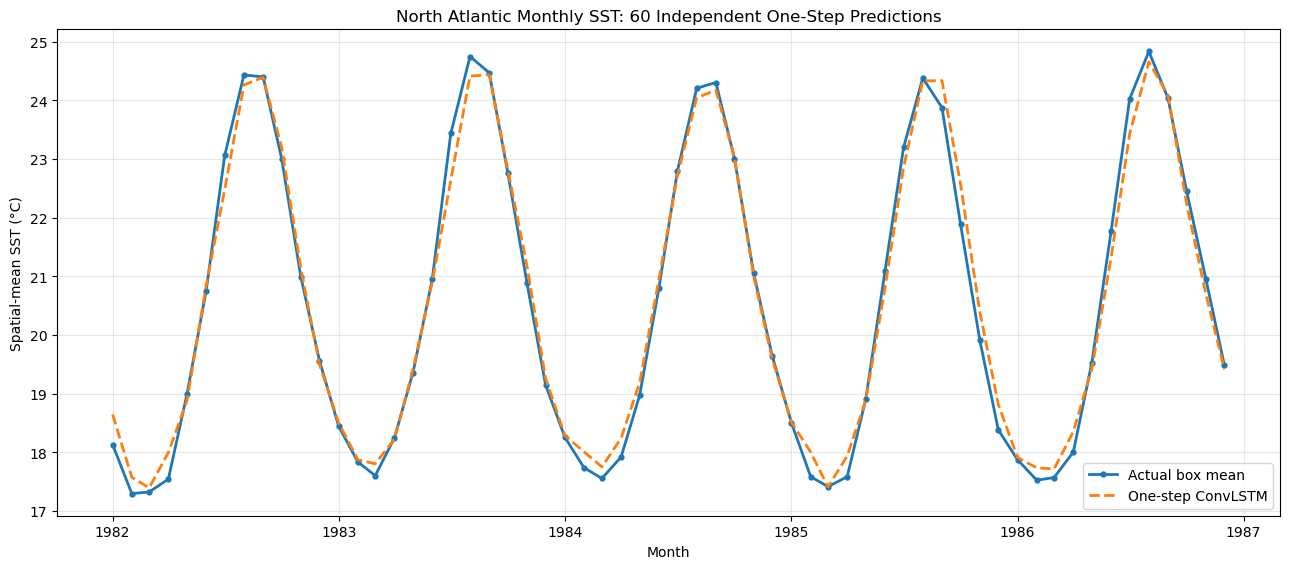

In [18]:
# Monthly box avg sst for whole period

actual_spatial_mean = np.nanmean(
    y_test_true[..., primary_index],
    axis=(1, 2),
)

predicted_spatial_mean = np.nanmean(
    y_test_pred[..., primary_index],
    axis=(1, 2),
)

plt.figure(figsize=(13, 5.8))

plt.plot(
    test_times,
    actual_spatial_mean,
    marker="o",
    markersize=3.5,
    linewidth=2,
    label="Actual box mean",
)

plt.plot(
    test_times,
    predicted_spatial_mean,
    linestyle="--",
    linewidth=2,
    label="One-step ConvLSTM",
)

plt.xlabel("Month")
plt.ylabel("Spatial-mean SST (°C)")
plt.title(
    "North Atlantic Monthly SST: 60 Independent One-Step Predictions"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


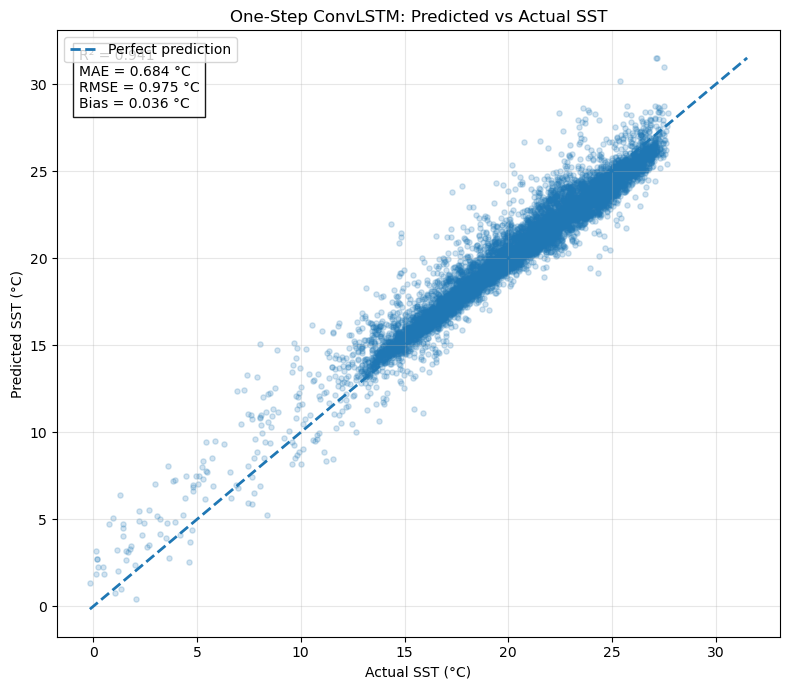

In [19]:
# Predicted vs actual scatter

rng = np.random.default_rng(42)

actual_flat = y_test_true[..., primary_index].ravel()
predicted_flat = y_test_pred[..., primary_index].ravel()

valid = (
    np.isfinite(actual_flat)
    & np.isfinite(predicted_flat)
)

actual_valid = actual_flat[valid]
predicted_valid = predicted_flat[valid]

sample_size = min(10_000, len(actual_valid))

sample_indices = rng.choice(
    len(actual_valid),
    size=sample_size,
    replace=False,
)

sample_actual = actual_valid[sample_indices]
sample_predicted = predicted_valid[sample_indices]

limits = [
    min(sample_actual.min(), sample_predicted.min()),
    max(sample_actual.max(), sample_predicted.max()),
]

scatter_metrics = safe_metrics(
    actual_valid,
    predicted_valid,
)

plt.figure(figsize=(8, 7))

plt.scatter(
    sample_actual,
    sample_predicted,
    alpha=0.20,
    s=14,
)

plt.plot(
    limits,
    limits,
    linestyle="--",
    linewidth=2,
    label="Perfect prediction",
)

plt.xlabel("Actual SST (°C)")
plt.ylabel("Predicted SST (°C)")
plt.title("One-Step ConvLSTM: Predicted vs Actual SST")
plt.grid(alpha=0.3)
plt.legend()

plt.text(
    0.03,
    0.97,
    (
        f"R² = {scatter_metrics['R2']:.3f}\n"
        f"MAE = {scatter_metrics['MAE']:.3f} °C\n"
        f"RMSE = {scatter_metrics['RMSE']:.3f} °C\n"
        f"Bias = {scatter_metrics['Bias']:.3f} °C"
    ),
    transform=plt.gca().transAxes,
    va="top",
    bbox={
        "facecolor": "white",
        "alpha": 0.9,
    },
)

plt.tight_layout()
plt.show()


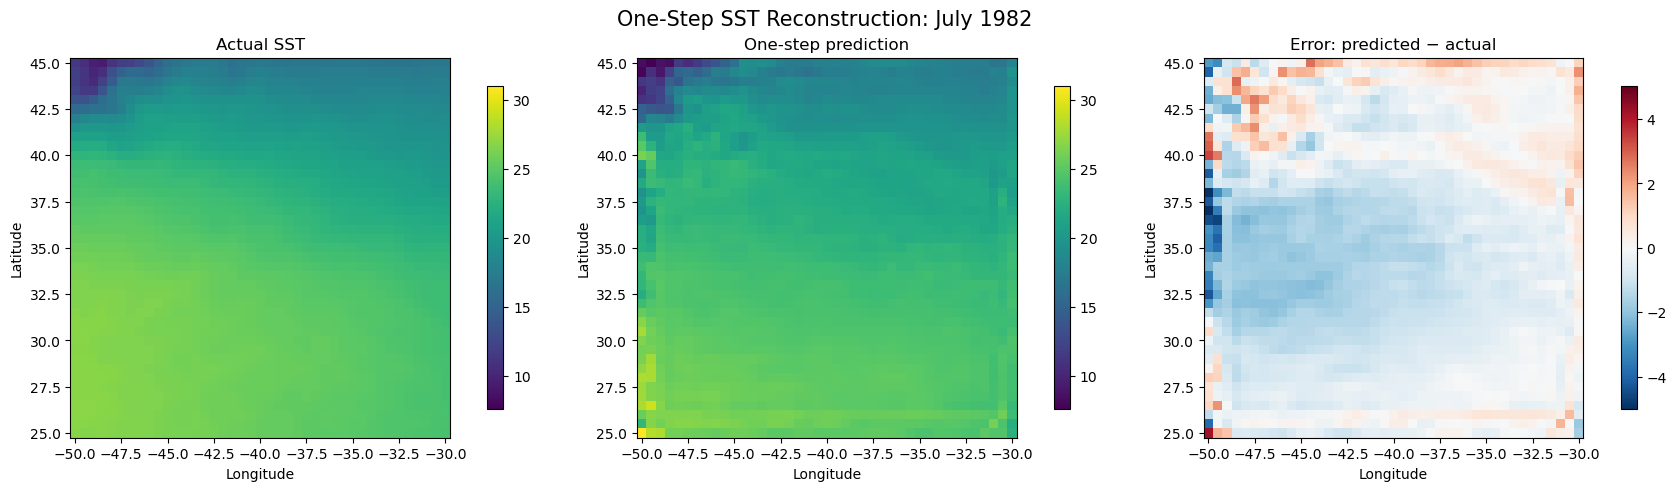

In [20]:
# Maps

SAMPLE_MONTH = pd.Timestamp("1982-07-01")
sample_index = test_times.get_loc(SAMPLE_MONTH)

actual_map = y_test_true[
    sample_index,
    ...,
    primary_index,
]

predicted_map = y_test_pred[
    sample_index,
    ...,
    primary_index,
]

error_map = predicted_map - actual_map

common_vmin = np.nanmin([actual_map, predicted_map])
common_vmax = np.nanmax([actual_map, predicted_map])
error_limit = np.nanmax(np.abs(error_map))

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.8),
    constrained_layout=True,
)

plots = [
    (
        actual_map,
        "Actual SST",
        common_vmin,
        common_vmax,
        "viridis",
    ),
    (
        predicted_map,
        "One-step prediction",
        common_vmin,
        common_vmax,
        "viridis",
    ),
    (
        error_map,
        "Error: predicted − actual",
        -error_limit,
        error_limit,
        "RdBu_r",
    ),
]

for ax, (field, title, vmin, vmax, cmap) in zip(
    axes,
    plots,
):
    mesh = ax.pcolormesh(
        lons,
        lats,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.set_aspect("equal")

    fig.colorbar(
        mesh,
        ax=ax,
        shrink=0.85,
    )

fig.suptitle(
    f"One-Step SST Reconstruction: {SAMPLE_MONTH:%B %Y}",
    fontsize=15,
)

plt.show()


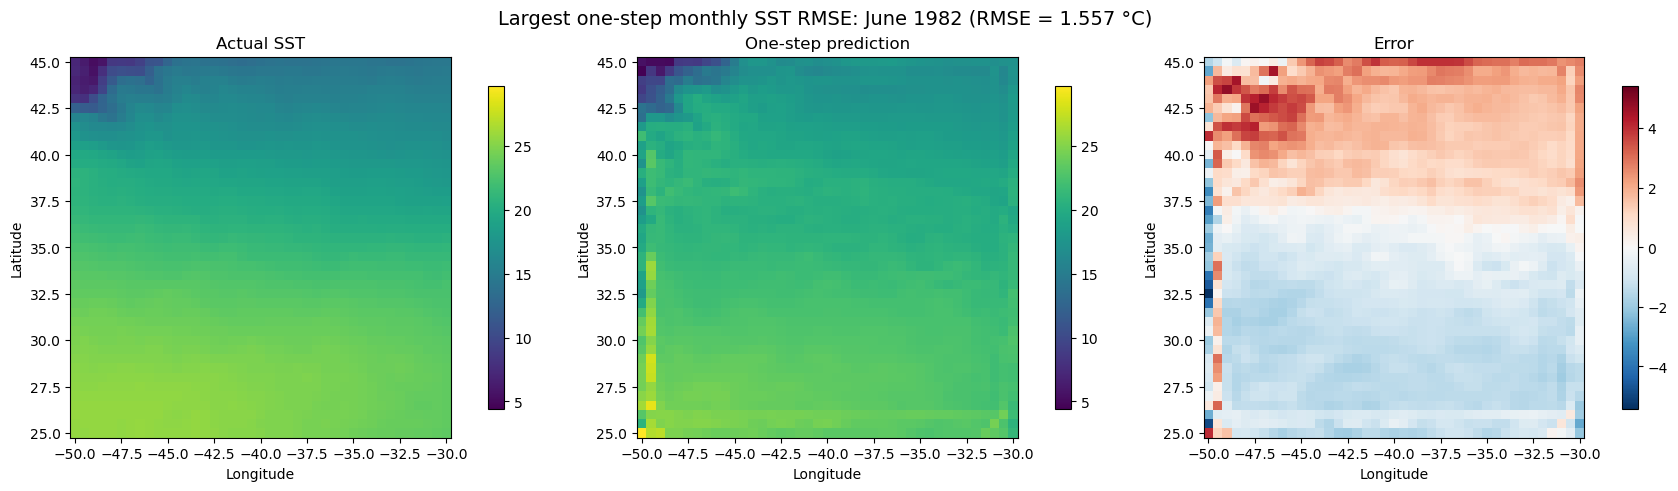

In [21]:
# Worst month

monthly_rmse = []

for month_index in range(len(test_times)):
    metrics = safe_metrics(
        y_test_true[
            month_index,
            ...,
            primary_index,
        ],
        y_test_pred[
            month_index,
            ...,
            primary_index,
        ],
    )

    monthly_rmse.append(metrics["RMSE"])

monthly_rmse = np.asarray(monthly_rmse)

worst_index = int(np.nanargmax(monthly_rmse))
worst_month = test_times[worst_index]

actual_extreme = y_test_true[
    worst_index,
    ...,
    primary_index,
]

predicted_extreme = y_test_pred[
    worst_index,
    ...,
    primary_index,
]

error_extreme = (
    predicted_extreme
    - actual_extreme
)

common_vmin = np.nanmin([
    actual_extreme,
    predicted_extreme,
])

common_vmax = np.nanmax([
    actual_extreme,
    predicted_extreme,
])

error_limit = np.nanmax(
    np.abs(error_extreme)
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.8),
    constrained_layout=True,
)

plots = [
    (
        actual_extreme,
        "Actual SST",
        common_vmin,
        common_vmax,
        "viridis",
    ),
    (
        predicted_extreme,
        "One-step prediction",
        common_vmin,
        common_vmax,
        "viridis",
    ),
    (
        error_extreme,
        "Error",
        -error_limit,
        error_limit,
        "RdBu_r",
    ),
]

for ax, (field, title, vmin, vmax, cmap) in zip(
    axes,
    plots,
):
    mesh = ax.pcolormesh(
        lons,
        lats,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.set_aspect("equal")

    fig.colorbar(
        mesh,
        ax=ax,
        shrink=0.85,
    )

fig.suptitle(
    f"Largest one-step monthly SST RMSE: "
    f"{worst_month:%B %Y} "
    f"(RMSE = {monthly_rmse[worst_index]:.3f} °C)",
    fontsize=14,
)

plt.show()


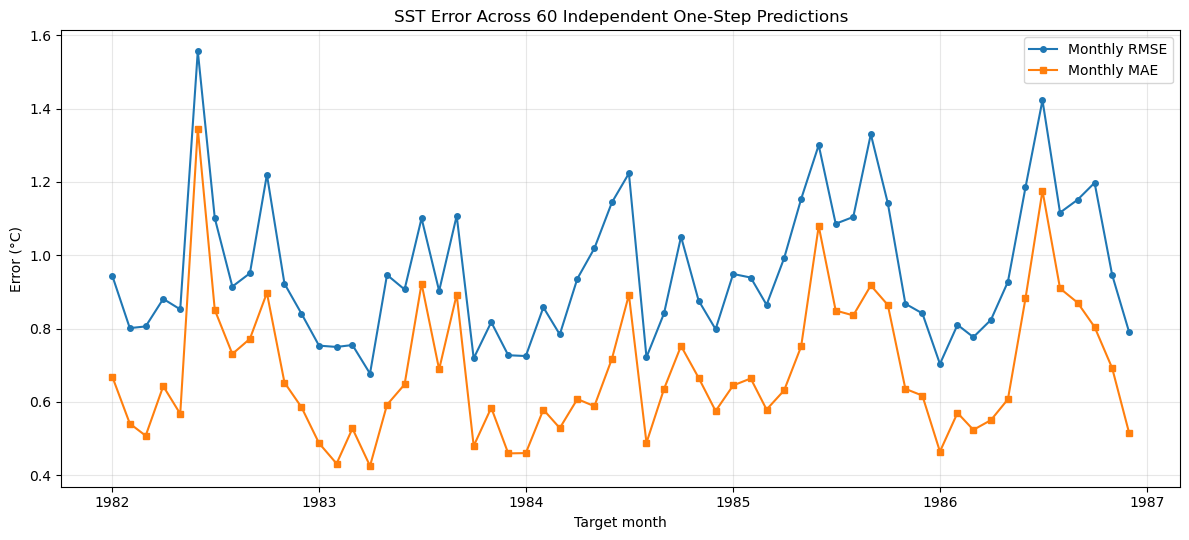

,date,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,1982-01-01,0.669363,0.944634,0.916239,0.513601,0.973175,1681
1,1982-02-01,0.541044,0.801401,0.941682,0.278205,0.975991,1681
2,1982-03-01,0.507858,0.805984,0.945863,0.070039,0.975685,1681
3,1982-04-01,0.643126,0.881143,0.932316,0.454781,0.976781,1681
4,1982-05-01,0.567536,0.852500,0.927074,-0.111144,0.963491,1681
5,1982-06-01,1.345102,1.556958,0.834940,0.088841,0.945033,1681
6,1982-07-01,0.851036,1.101307,0.877667,-0.579793,0.956215,1681
7,1982-08-01,0.730931,0.914733,0.858082,-0.171774,0.937499,1681
8,1982-09-01,0.772244,0.951080,0.839807,-0.007878,0.931576,1681
9,1982-10-01,0.897538,1.219971,0.851378,0.193163,0.955663,1681


In [22]:
# Monthly error

monthly_rows = []

for month_index, timestamp in enumerate(test_times):
    metrics = safe_metrics(
        y_test_true[
            month_index,
            ...,
            primary_index,
        ],
        y_test_pred[
            month_index,
            ...,
            primary_index,
        ],
    )

    monthly_rows.append({
        "date": timestamp,
        **metrics,
    })

monthly_metrics_df = pd.DataFrame(monthly_rows)

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(
    monthly_metrics_df["date"],
    monthly_metrics_df["RMSE"],
    marker="o",
    markersize=4,
    label="Monthly RMSE",
)

ax.plot(
    monthly_metrics_df["date"],
    monthly_metrics_df["MAE"],
    marker="s",
    markersize=4,
    label="Monthly MAE",
)

ax.set_xlabel("Target month")
ax.set_ylabel("Error (°C)")
ax.set_title(
    "SST Error Across 60 Independent One-Step Predictions"
)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

display(monthly_metrics_df)


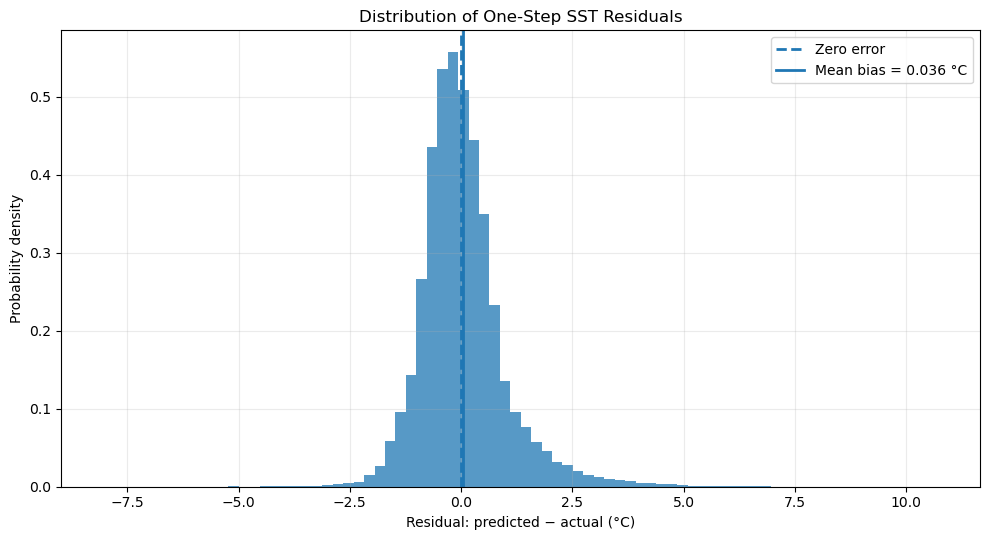

Residual standard deviation: 0.9741824
Residual median: -0.08084011
95th percentile absolute error: 1.9481863021850585


In [23]:
# Residual distribution

residuals = predicted_valid - actual_valid

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(
    residuals,
    bins=80,
    density=True,
    alpha=0.75,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Zero error",
)

ax.axvline(
    np.mean(residuals),
    linewidth=2,
    label=f"Mean bias = {np.mean(residuals):.3f} °C",
)

ax.set_xlabel("Residual: predicted − actual (°C)")
ax.set_ylabel("Probability density")
ax.set_title("Distribution of One-Step SST Residuals")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print("Residual standard deviation:", np.std(residuals))
print("Residual median:", np.median(residuals))
print(
    "95th percentile absolute error:",
    np.percentile(np.abs(residuals), 95),
)


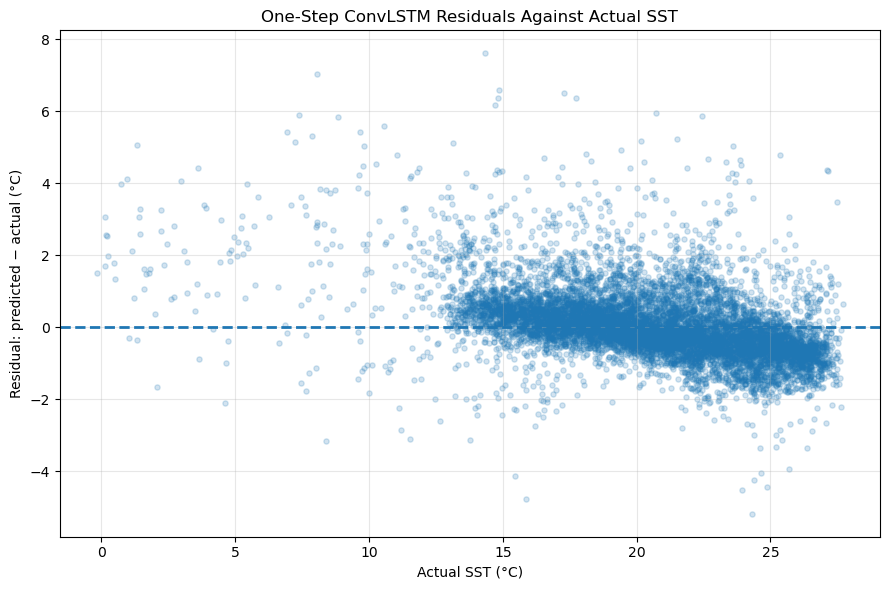

In [24]:
# Residuals against actual sst

sample_residuals = (
    sample_predicted
    - sample_actual
)

plt.figure(figsize=(9, 6))

plt.scatter(
    sample_actual,
    sample_residuals,
    alpha=0.20,
    s=14,
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Actual SST (°C)")
plt.ylabel("Residual: predicted − actual (°C)")
plt.title("One-Step ConvLSTM Residuals Against Actual SST")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


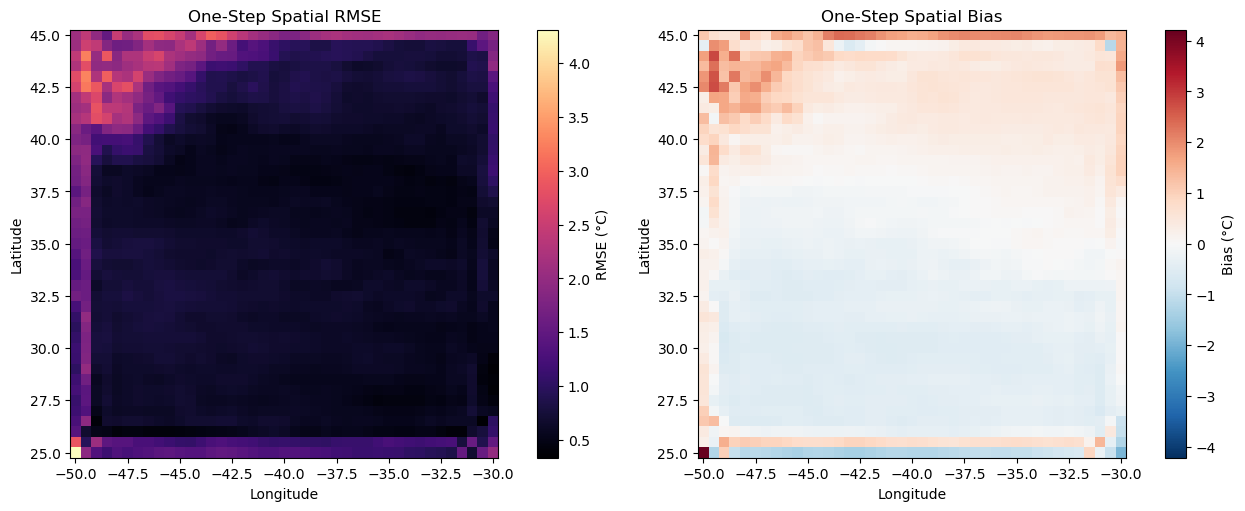

In [25]:
# RMSE and bias maps

actual_primary = y_test_true[
    ...,
    primary_index,
]

predicted_primary = y_test_pred[
    ...,
    primary_index,
]

spatial_error = (
    predicted_primary
    - actual_primary
)

spatial_rmse = np.sqrt(
    np.nanmean(
        spatial_error ** 2,
        axis=0,
    )
)

spatial_bias = np.nanmean(
    spatial_error,
    axis=0,
)

bias_limit = np.nanmax(
    np.abs(spatial_bias)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5),
    constrained_layout=True,
)

rmse_mesh = axes[0].pcolormesh(
    lons,
    lats,
    spatial_rmse,
    shading="auto",
    cmap="magma",
)

axes[0].set_title("One-Step Spatial RMSE")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

fig.colorbar(
    rmse_mesh,
    ax=axes[0],
    label="RMSE (°C)",
)

bias_mesh = axes[1].pcolormesh(
    lons,
    lats,
    spatial_bias,
    shading="auto",
    cmap="RdBu_r",
    vmin=-bias_limit,
    vmax=bias_limit,
)

axes[1].set_title("One-Step Spatial Bias")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_aspect("equal")

fig.colorbar(
    bias_mesh,
    ax=axes[1],
    label="Bias (°C)",
)

plt.show()


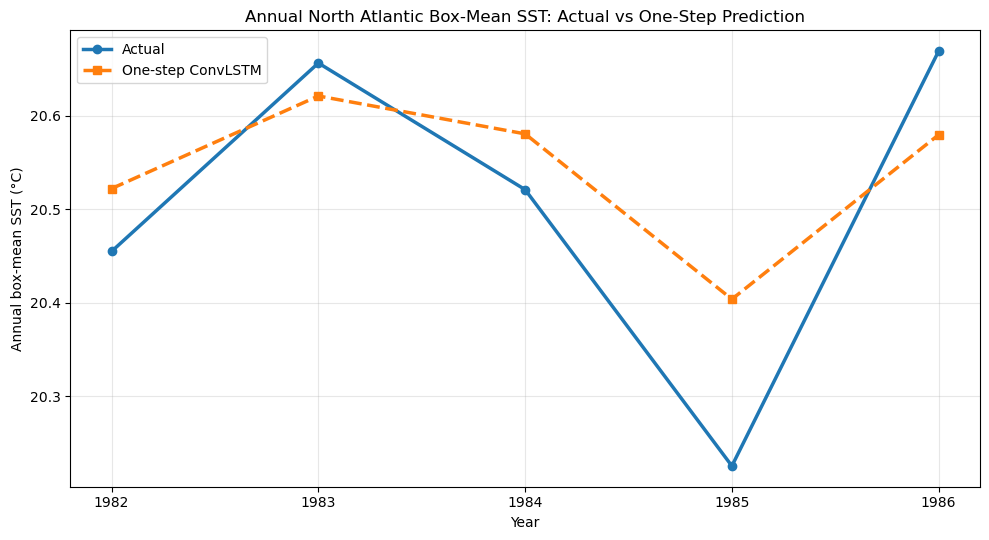

,year,actual,predicted
0,1982,20.454927,20.522099
1,1983,20.656385,20.621132
2,1984,20.520947,20.580605
3,1985,20.225365,20.403772
4,1986,20.669170,20.579678


In [26]:
# Annual vs predicted box avg sst

annual_rows = []

for year in range(TEST_START.year, TEST_END.year + 1):
    year_mask = test_times.year == year

    annual_rows.append({
        "year": year,
        "actual": np.nanmean(
            y_test_true[
                year_mask,
                ...,
                primary_index,
            ]
        ),
        "predicted": np.nanmean(
            y_test_pred[
                year_mask,
                ...,
                primary_index,
            ]
        ),
    })

annual_mean_df = pd.DataFrame(annual_rows)

plt.figure(figsize=(10, 5.5))

plt.plot(
    annual_mean_df["year"],
    annual_mean_df["actual"],
    marker="o",
    linewidth=2.5,
    label="Actual",
)

plt.plot(
    annual_mean_df["year"],
    annual_mean_df["predicted"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label="One-step ConvLSTM",
)

plt.xlabel("Year")
plt.ylabel("Annual box-mean SST (°C)")
plt.title(
    "Annual North Atlantic Box-Mean SST: Actual vs One-Step Prediction"
)
plt.xticks(annual_mean_df["year"])
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

display(annual_mean_df)


,year,mean_relative_difference,standard_deviation,standard_error_of_mean,n_months
0,1982,-0.004351,0.014725,0.004251,12
1,1983,0.000878,0.012530,0.003617,12
2,1984,-0.003686,0.008502,0.002454,12
3,1985,-0.009261,0.016071,0.004639,12
4,1986,0.003280,0.012962,0.003742,12


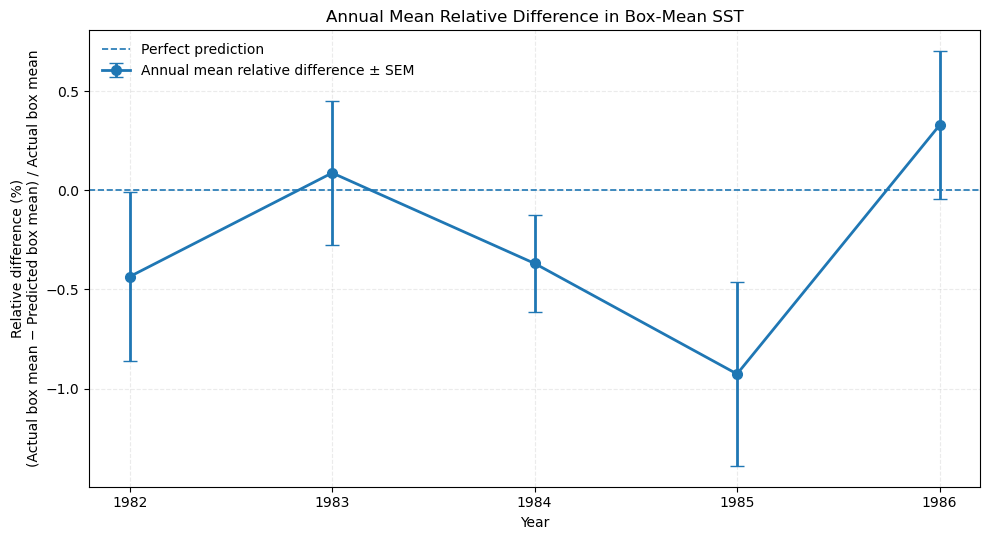

In [27]:
# Annual avg rel difference in monthly box avg
# For each month: (actual box mean - predicted box mean) / actual box mean
# The annual uncertainty is the SEM across the 12 monthly box-mean values

monthly_actual_box_mean = np.nanmean(
    y_test_true[..., primary_index],
    axis=(1, 2),
)

monthly_predicted_box_mean = np.nanmean(
    y_test_pred[..., primary_index],
    axis=(1, 2),
)

monthly_relative_difference = (
    monthly_actual_box_mean
    - monthly_predicted_box_mean
) / monthly_actual_box_mean

monthly_box_results_df = pd.DataFrame({
    "time": test_times,
    "year": test_times.year,
    "actual_box_mean_sst": monthly_actual_box_mean,
    "predicted_box_mean_sst": monthly_predicted_box_mean,
    "relative_difference": monthly_relative_difference,
})

annual_relative_rows = []

for year, year_df in monthly_box_results_df.groupby("year"):
    values = year_df[
        "relative_difference"
    ].to_numpy()

    values = values[
        np.isfinite(values)
    ]

    n_months = len(values)

    annual_mean = np.mean(values)

    annual_std = (
        np.std(values, ddof=1)
        if n_months > 1
        else np.nan
    )

    annual_sem = (
        annual_std / np.sqrt(n_months)
        if n_months > 1
        else np.nan
    )

    annual_relative_rows.append({
        "year": int(year),
        "mean_relative_difference": annual_mean,
        "standard_deviation": annual_std,
        "standard_error_of_mean": annual_sem,
        "n_months": n_months,
    })

annual_relative_difference_df = pd.DataFrame(
    annual_relative_rows
)

display(annual_relative_difference_df)

years_plot = annual_relative_difference_df[
    "year"
].to_numpy()

mean_percent = (
    annual_relative_difference_df[
        "mean_relative_difference"
    ].to_numpy()
    * 100
)

sem_percent = (
    annual_relative_difference_df[
        "standard_error_of_mean"
    ].to_numpy()
    * 100
)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.errorbar(
    years_plot,
    mean_percent,
    yerr=sem_percent,
    marker="o",
    markersize=7,
    linewidth=2,
    capsize=5,
    label="Annual mean relative difference ± SEM",
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    label="Perfect prediction",
)

ax.set_title(
    "Annual Mean Relative Difference in Box-Mean SST"
)
ax.set_xlabel("Year")
ax.set_ylabel(
    "Relative difference (%)\n"
    "(Actual box mean − Predicted box mean) / Actual box mean"
)
ax.set_xticks(years_plot)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


1982: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries
1983: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries
1984: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries
1985: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries
1986: 12 × 41 × 41 = 20,172 possible entries; 20,172 valid entries


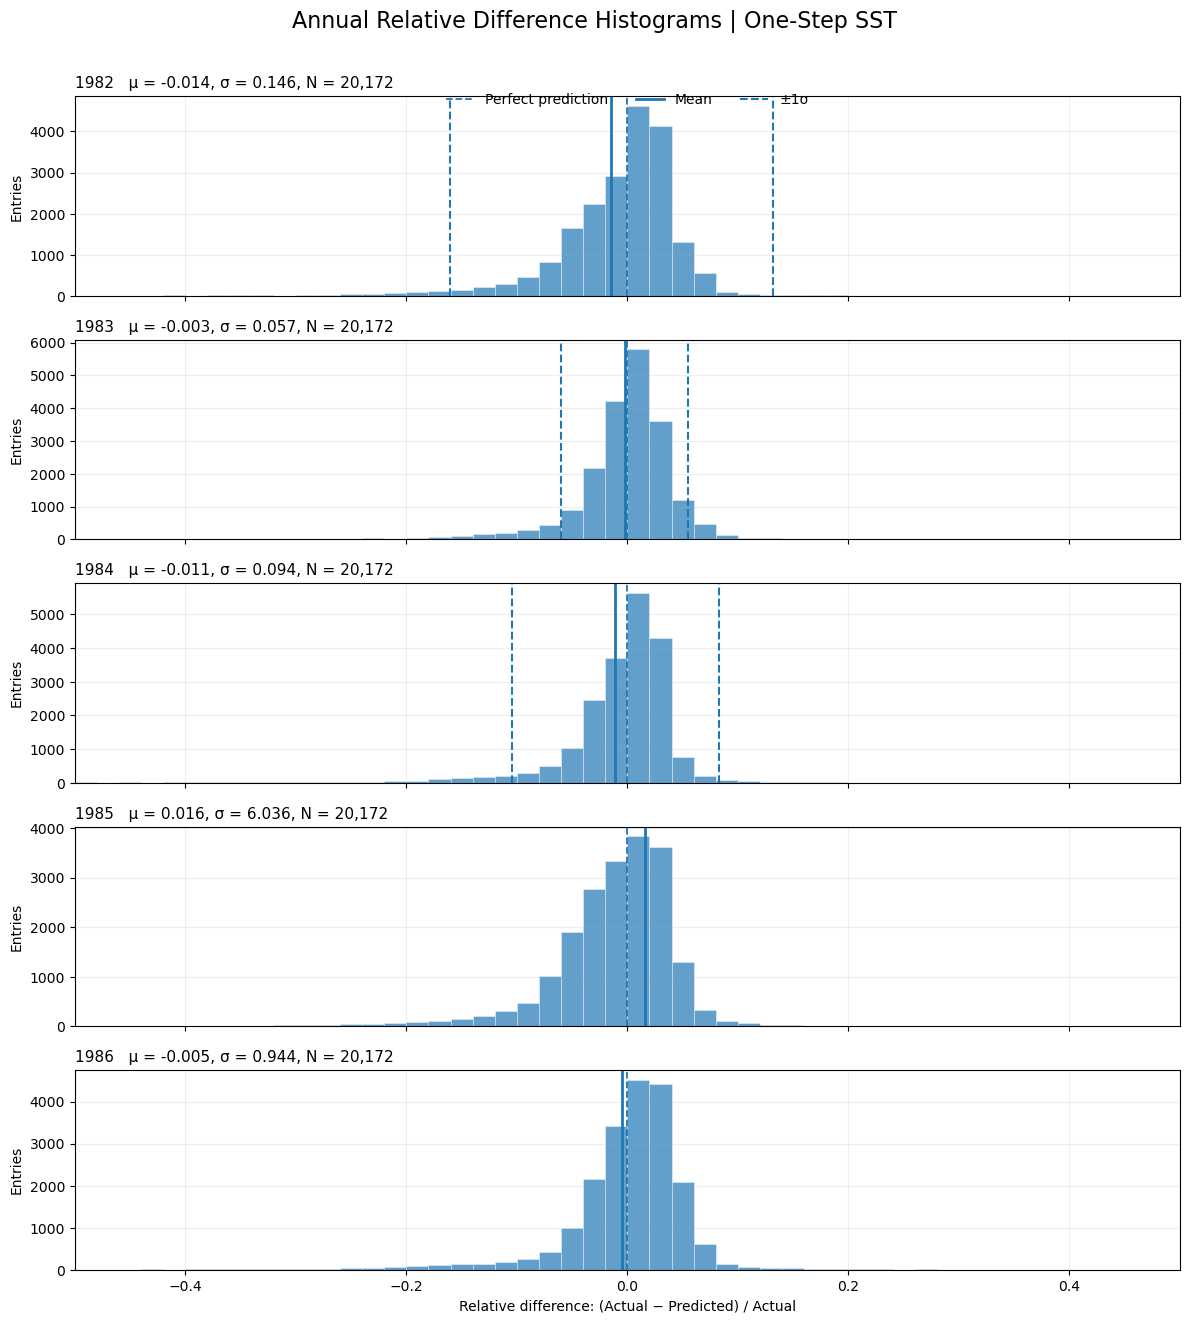

,year,mean,standard_deviation,standard_error_of_mean,n_entries
0,1982,-0.014388,0.146119,0.001029,20172
1,1983,-0.002515,0.057412,0.000404,20172
2,1984,-0.010983,0.093787,0.000660,20172
3,1985,0.016042,6.036018,0.042499,20172
4,1986,-0.005033,0.944296,0.006649,20172


In [28]:
# Anual rel difference histograms
# 12 months × 41 × 41 cells = 20,172 entries

actual_sst = y_test_true[..., primary_index]
predicted_sst = y_test_pred[..., primary_index]

minimum_absolute_sst = 1e-6

cell_month_relative_difference = np.full(
    actual_sst.shape,
    np.nan,
    dtype=np.float64,
)

valid = (
    np.isfinite(actual_sst)
    & np.isfinite(predicted_sst)
    & (np.abs(actual_sst) > minimum_absolute_sst)
)

cell_month_relative_difference[valid] = (
    actual_sst[valid]
    - predicted_sst[valid]
) / actual_sst[valid]

test_years = np.unique(test_times.year)
annual_values = {}

for year in test_years:
    year_mask = test_times.year == year

    year_array = cell_month_relative_difference[
        year_mask
    ]

    values = year_array.ravel()
    values = values[np.isfinite(values)]

    annual_values[int(year)] = values

    print(
        f"{int(year)}: "
        f"{year_array.shape[0]} × "
        f"{year_array.shape[1]} × "
        f"{year_array.shape[2]} = "
        f"{year_array.size:,} possible entries; "
        f"{values.size:,} valid entries"
    )

x_min = -0.5
x_max = 0.5
n_bins = 50

shared_bins = np.linspace(
    x_min,
    x_max,
    n_bins + 1,
)

n_years = len(test_years)

fig, axes = plt.subplots(
    nrows=n_years,
    ncols=1,
    figsize=(12, 2.65 * n_years),
    sharex=True,
)

if n_years == 1:
    axes = [axes]

fig.suptitle(
    "Annual Relative Difference Histograms | One-Step SST",
    fontsize=16,
    y=0.995,
)

summary_rows = []

for plot_index, year in enumerate(test_years):
    ax = axes[plot_index]
    values = annual_values[int(year)]

    mean_error = np.mean(values)
    standard_deviation = np.std(values, ddof=1)
    standard_error = (
        standard_deviation
        / np.sqrt(values.size)
    )

    summary_rows.append({
        "year": int(year),
        "mean": mean_error,
        "standard_deviation": standard_deviation,
        "standard_error_of_mean": standard_error,
        "n_entries": values.size,
    })

    ax.hist(
        values,
        bins=shared_bins,
        alpha=0.70,
        edgecolor="white",
        linewidth=0.4,
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.3,
        label=(
            "Perfect prediction"
            if plot_index == 0
            else None
        ),
    )

    ax.axvline(
        mean_error,
        linewidth=2,
        label=(
            "Mean"
            if plot_index == 0
            else None
        ),
    )

    ax.axvline(
        mean_error - standard_deviation,
        linestyle="--",
        linewidth=1.5,
        label=(
            "±1σ"
            if plot_index == 0
            else None
        ),
    )

    ax.axvline(
        mean_error + standard_deviation,
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylabel("Entries")

    ax.set_title(
        (
            f"{int(year)}   "
            f"μ = {mean_error:.3f}, "
            f"σ = {standard_deviation:.3f}, "
            f"N = {values.size:,}"
        ),
        loc="left",
        fontsize=11,
        pad=6,
    )

    ax.grid(alpha=0.20)

axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
)

axes[-1].set_xlabel(
    "Relative difference: (Actual − Predicted) / Actual"
)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

annual_histogram_summary_df = pd.DataFrame(
    summary_rows
)

display(annual_histogram_summary_df)


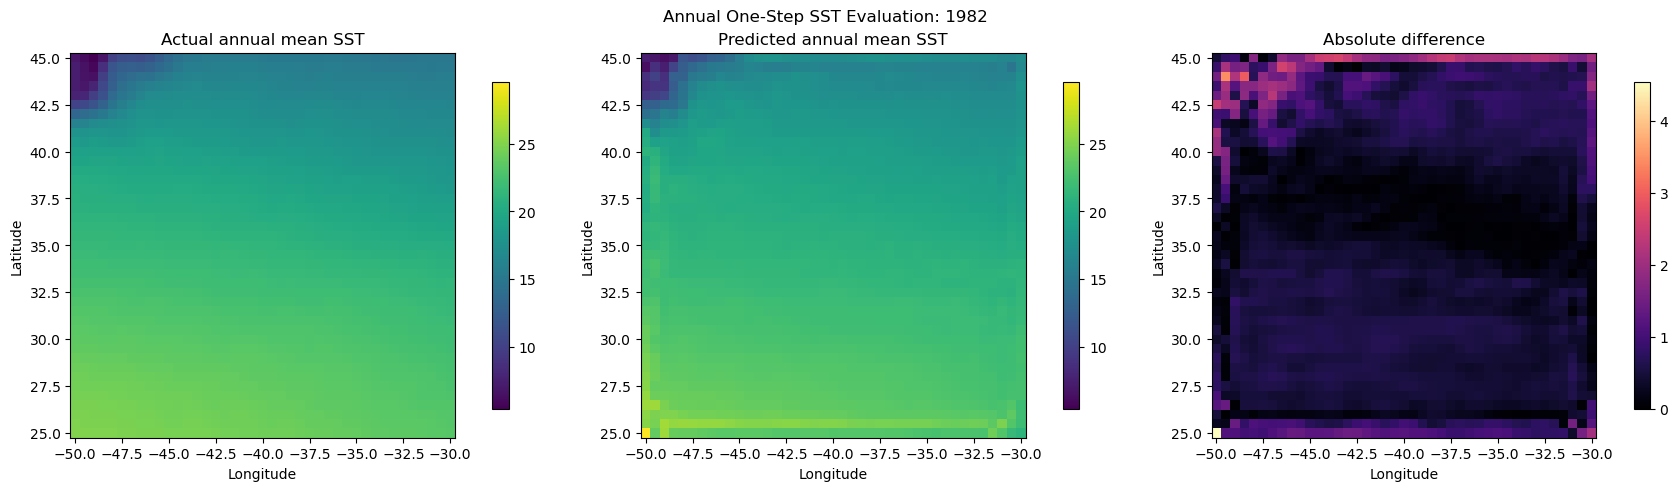

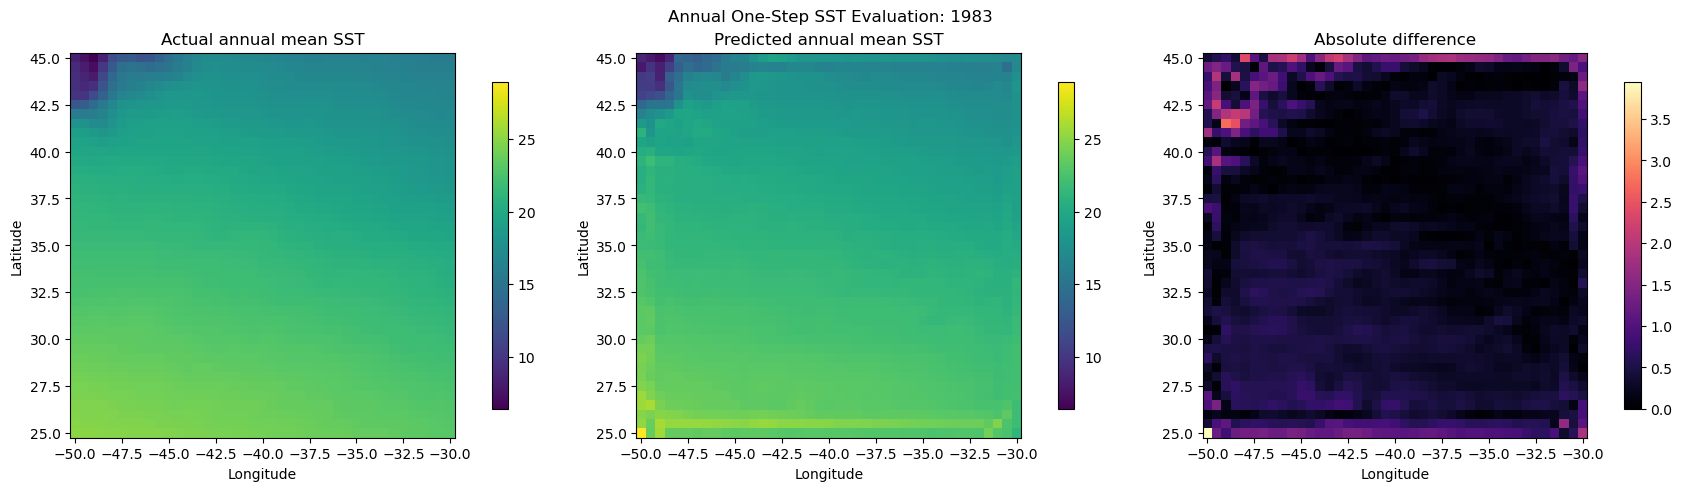

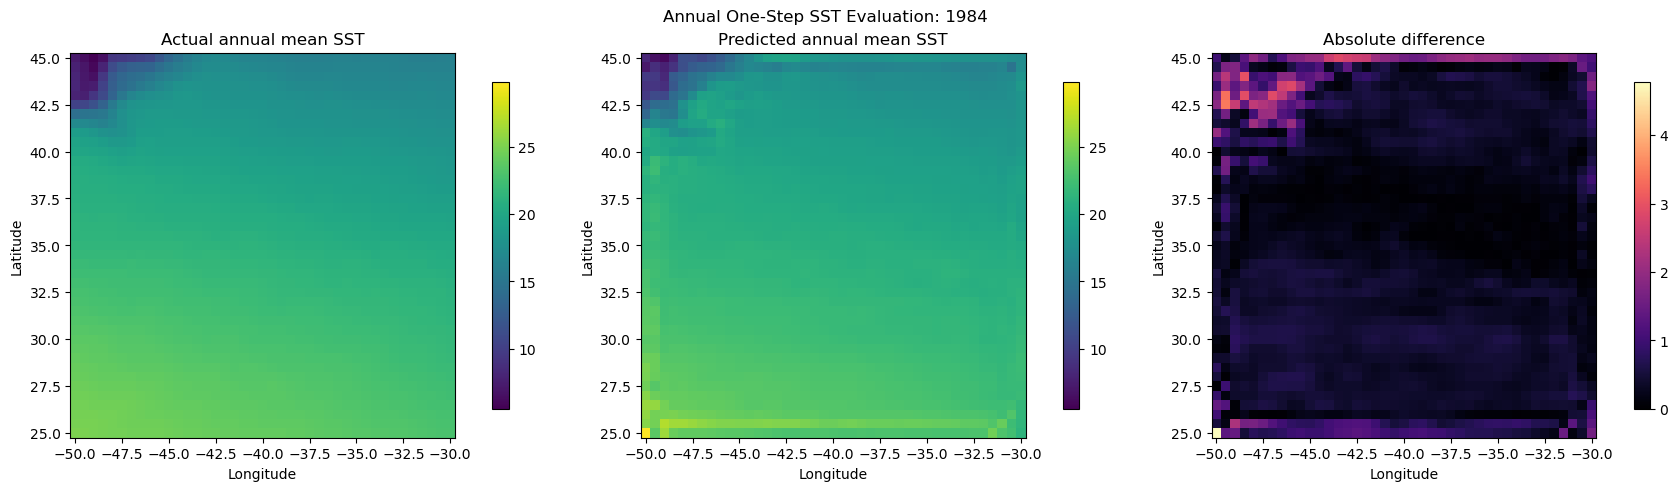

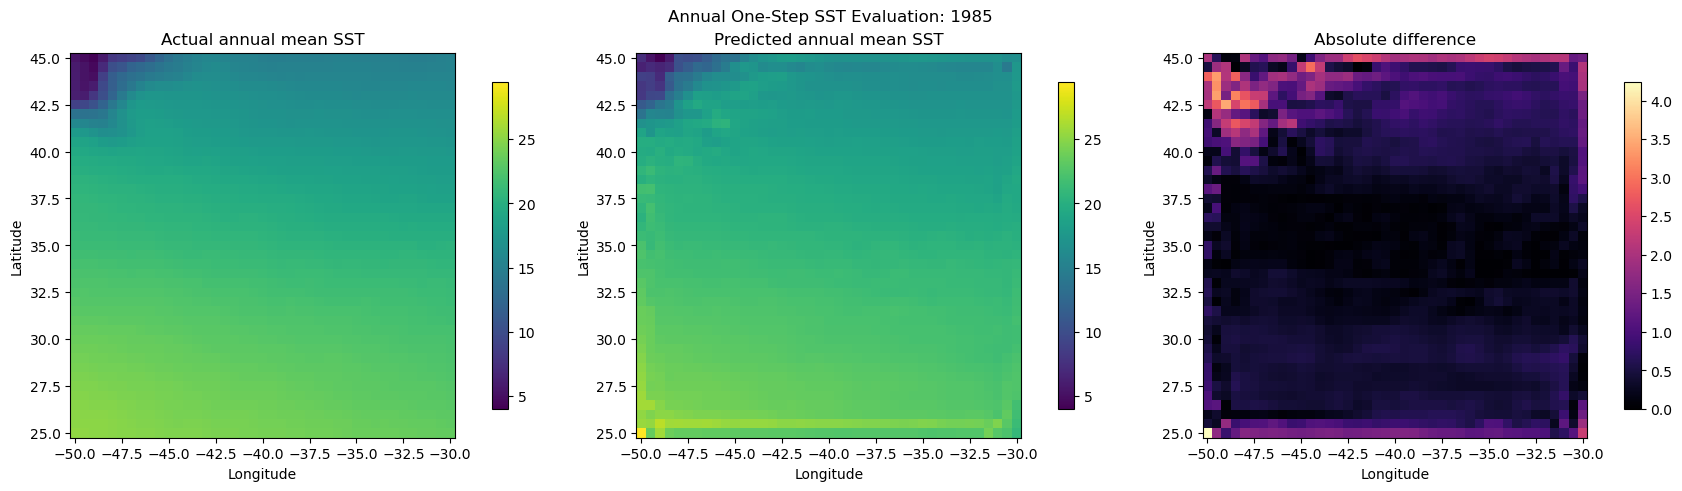

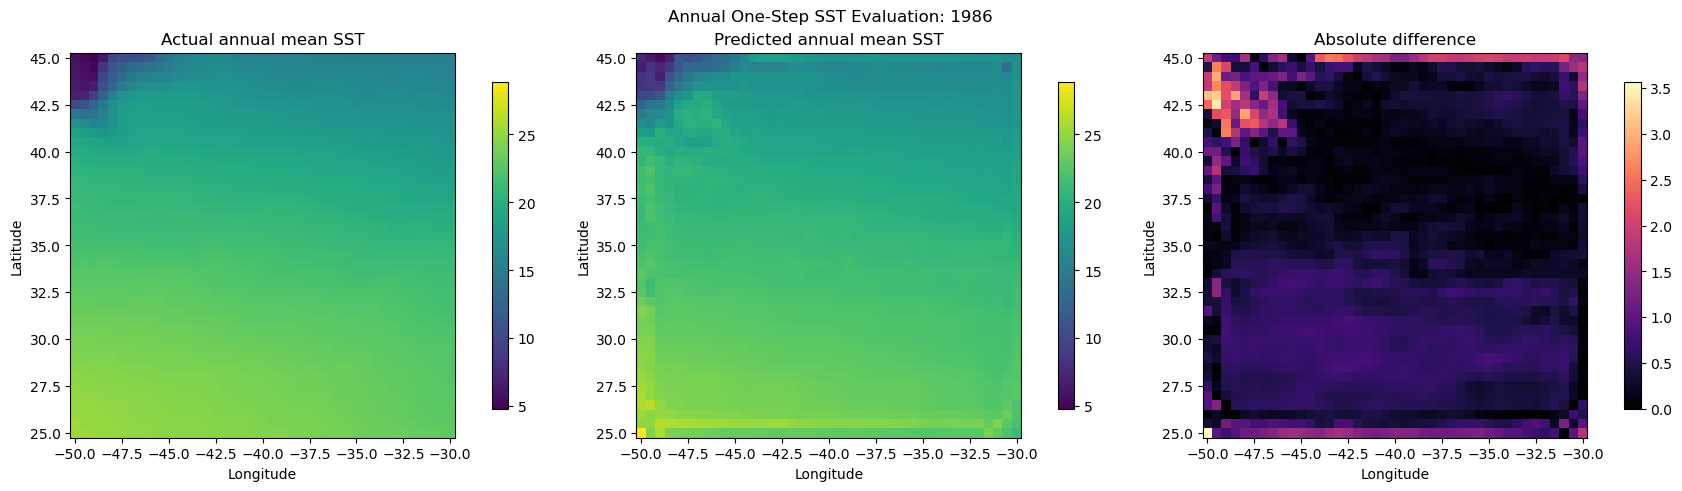

In [29]:
# Maps

for year in range(TEST_START.year, TEST_END.year + 1):
    year_mask = test_times.year == year

    actual_map = np.nanmean(
        y_test_true[
            year_mask,
            ...,
            primary_index,
        ],
        axis=0,
    )

    predicted_map = np.nanmean(
        y_test_pred[
            year_mask,
            ...,
            primary_index,
        ],
        axis=0,
    )

    absolute_difference = np.abs(
        predicted_map
        - actual_map
    )

    common_vmin = np.nanmin([
        actual_map,
        predicted_map,
    ])

    common_vmax = np.nanmax([
        actual_map,
        predicted_map,
    ])

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        constrained_layout=True,
    )

    fields = [
        (
            actual_map,
            "Actual annual mean SST",
            common_vmin,
            common_vmax,
            "viridis",
        ),
        (
            predicted_map,
            "Predicted annual mean SST",
            common_vmin,
            common_vmax,
            "viridis",
        ),
        (
            absolute_difference,
            "Absolute difference",
            0,
            np.nanmax(absolute_difference),
            "magma",
        ),
    ]

    for ax, (field, title, vmin, vmax, cmap) in zip(
        axes,
        fields,
    ):
        mesh = ax.pcolormesh(
            lons,
            lats,
            field,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_aspect("equal")

        fig.colorbar(
            mesh,
            ax=ax,
            shrink=0.85,
        )

    fig.suptitle(
        f"Annual One-Step SST Evaluation: {year}"
    )

    plt.show()


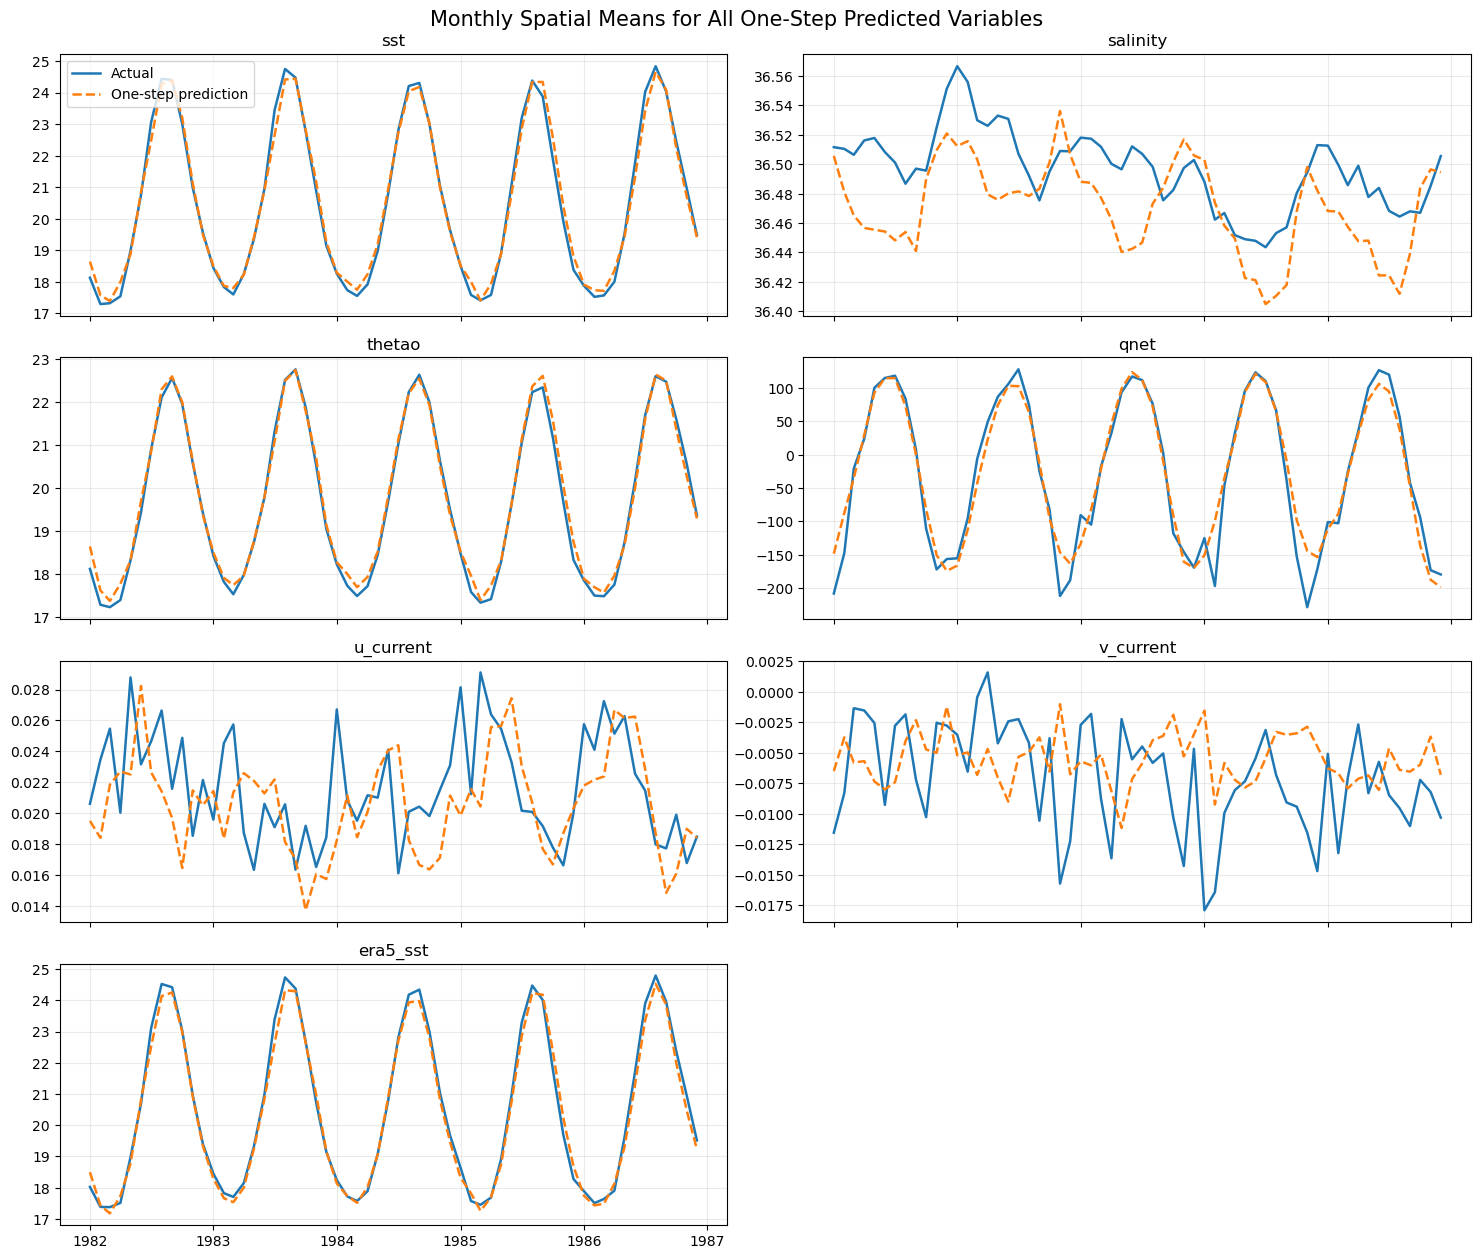

In [30]:
# Feature monthly spatial means

n_features = len(features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 3.2 * n_rows),
    sharex=True,
)

axes = np.asarray(axes).ravel()

for feature_index, feature_name in enumerate(features):
    actual_mean = np.nanmean(
        y_test_true[..., feature_index],
        axis=(1, 2),
    )

    predicted_mean = np.nanmean(
        y_test_pred[..., feature_index],
        axis=(1, 2),
    )

    ax = axes[feature_index]

    ax.plot(
        test_times,
        actual_mean,
        linewidth=1.8,
        label="Actual",
    )

    ax.plot(
        test_times,
        predicted_mean,
        linestyle="--",
        linewidth=1.8,
        label="One-step prediction",
    )

    ax.set_title(feature_name)
    ax.grid(alpha=0.25)

for ax in axes[n_features:]:
    ax.axis("off")

axes[0].legend()

fig.suptitle(
    "Monthly Spatial Means for All One-Step Predicted Variables",
    fontsize=15,
)

plt.tight_layout()
plt.show()


## 7. Save results

In [31]:
# Save tables/arrays

one_step_metrics_df.to_csv(
    OUTPUT_DIR / "one_step_metrics_by_feature.csv",
    index=False,
)

baseline_comparison_df.to_csv(
    OUTPUT_DIR / "one_step_persistence_comparison.csv",
    index=False,
)

forecast_period_metrics_df.to_csv(
    OUTPUT_DIR / "sst_metrics_by_evaluation_period.csv",
    index=False,
)

yearly_metrics_df.to_csv(
    OUTPUT_DIR / "metrics_by_year_and_feature.csv",
    index=False,
)

monthly_metrics_df.to_csv(
    OUTPUT_DIR / "sst_metrics_by_month.csv",
    index=False,
)

annual_mean_df.to_csv(
    OUTPUT_DIR / "sst_annual_box_mean.csv",
    index=False,
)

annual_relative_difference_df.to_csv(
    OUTPUT_DIR / "sst_annual_relative_difference.csv",
    index=False,
)

annual_histogram_summary_df.to_csv(
    OUTPUT_DIR / "sst_relative_histogram_summary.csv",
    index=False,
)

if comparison_df is not None:
    comparison_df.to_csv(
        OUTPUT_DIR / "one_step_vs_recursive_sst.csv",
        index=False,
    )

prediction_da = xr.DataArray(
    y_test_pred.transpose(0, 3, 1, 2),
    dims=("time", "feature", "lat", "lon"),
    coords={
        "time": test_times,
        "feature": features,
        "lat": lats,
        "lon": lons,
    },
    name="prediction",
)

truth_da = xr.DataArray(
    y_test_true.transpose(0, 3, 1, 2),
    dims=("time", "feature", "lat", "lon"),
    coords=prediction_da.coords,
    name="actual",
)

prediction_dataset = xr.Dataset({
    "prediction": prediction_da,
    "actual": truth_da,
    "error": prediction_da - truth_da,
})

prediction_dataset.to_netcdf(
    OUTPUT_DIR / "one_step_predictions_1982_1986.nc",
    engine="h5netcdf",
    encoding={
        name: {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
        }
        for name in prediction_dataset.data_vars
    },
)

print("Saved all outputs to:")
print(OUTPUT_DIR)


Saved all outputs to:
C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\ConvLSTM_one_step_1982_1986_results


In [32]:
# Summary

primary_metrics = one_step_metrics_df.loc[
    one_step_metrics_df["feature"] == PRIMARY_FEATURE
].iloc[0]

summary = pd.DataFrame([
    {
        "evaluation": "One-step-ahead SST",
        "MAE": primary_metrics["MAE"],
        "RMSE": primary_metrics["RMSE"],
        "R2": primary_metrics["R2"],
        "Bias": primary_metrics["Bias"],
        "Pearson_r": primary_metrics["Pearson_r"],
        "n_valid": primary_metrics["n_valid"],
    }
])

display(summary)

print(
    f'''
Across 60 independent one-step-ahead monthly predictions from
January 1982 to December 1986, the ConvLSTM achieved an SST MAE of
{primary_metrics["MAE"]:.3f} °C, an RMSE of
{primary_metrics["RMSE"]:.3f} °C and an R² of
{primary_metrics["R2"]:.3f}. The mean prediction bias was
{primary_metrics["Bias"]:.3f} °C and the Pearson correlation was
{primary_metrics["Pearson_r"]:.3f}.
'''
)


,evaluation,MAE,RMSE,R2,Bias,Pearson_r,n_valid
0,One-step-ahead SST,0.683956,0.974851,0.941287,0.036098,0.972203,100860



Across 60 independent one-step-ahead monthly predictions from
January 1982 to December 1986, the ConvLSTM achieved an SST MAE of
0.684 °C, an RMSE of
0.975 °C and an R² of
0.941. The mean prediction bias was
0.036 °C and the Pearson correlation was
0.972.



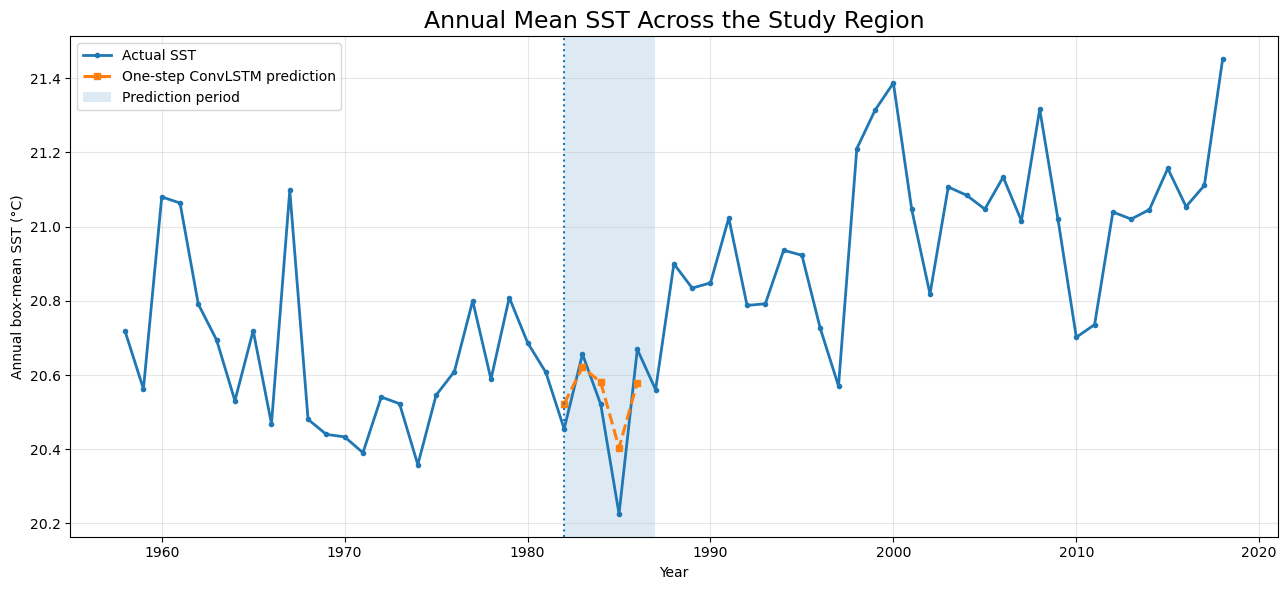

,year,predicted_mean_sst,n_months,actual_mean_sst,actual_minus_predicted
0,1982,20.522099,12,20.454927,-0.067171
1,1983,20.621132,12,20.656385,0.035254
2,1984,20.580603,12,20.520945,-0.059658
3,1985,20.403772,12,20.225365,-0.178408
4,1986,20.579678,12,20.669168,0.089491


In [34]:
# Annual avg sst

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

feature_name = "sst"
feature_idx = features.index(feature_name)

all_times = pd.DatetimeIndex(times)
prediction_times = pd.DatetimeIndex(test_times)

actual_monthly_box_mean = np.nanmean(
    raw_data[..., feature_idx],
    axis=(1, 2),
)


predicted_monthly_box_mean = np.nanmean(
    y_test_pred[..., feature_idx],
    axis=(1, 2),
)


actual_rows = []

for year in np.unique(all_times.year):
    year_mask = all_times.year == year

    values = actual_monthly_box_mean[year_mask]
    values = values[np.isfinite(values)]

    if values.size == 0:
        continue

    actual_rows.append({
        "year": int(year),
        "actual_mean_sst": np.mean(values),
        "n_months": values.size,
    })

actual_annual_df = pd.DataFrame(actual_rows)

prediction_rows = []

for year in np.unique(prediction_times.year):
    year_mask = prediction_times.year == year

    values = predicted_monthly_box_mean[year_mask]
    values = values[np.isfinite(values)]

    if values.size == 0:
        continue

    prediction_rows.append({
        "year": int(year),
        "predicted_mean_sst": np.mean(values),
        "n_months": values.size,
    })

predicted_annual_df = pd.DataFrame(prediction_rows)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    actual_annual_df["year"],
    actual_annual_df["actual_mean_sst"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="Actual SST",
)

ax.plot(
    predicted_annual_df["year"],
    predicted_annual_df["predicted_mean_sst"],
    marker="s",
    markersize=5,
    linestyle="--",
    linewidth=2.2,
    label="One-step ConvLSTM prediction",
)

# Start of test period
ax.axvline(
    TEST_START.year,
    linestyle=":",
    linewidth=1.5,
)

# Shade prediction period
ax.axvspan(
    TEST_START.year,
    TEST_END.year + 0.99,
    alpha=0.15,
    label="Prediction period",
)

ax.set_title(
    "Annual Mean SST Across the Study Region",
    fontsize=17,
)

ax.set_xlabel("Year")
ax.set_ylabel("Annual box-mean SST (°C)")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


annual_comparison_df = predicted_annual_df.merge(
    actual_annual_df[
        ["year", "actual_mean_sst"]
    ],
    on="year",
    how="left",
)

annual_comparison_df["actual_minus_predicted"] = (
    annual_comparison_df["actual_mean_sst"]
    - annual_comparison_df["predicted_mean_sst"]
)

display(annual_comparison_df)